# Integration with Jump Processes: from $N_t$ to the Poisson Random Measure $N(dt,dz)$
## Why we must use $N(t^-)$ / $X_{t^-}$

The whole point of the minus sign is **predictability**:

> At a jump time $t$, $N(t)$ already includes the jump at $t$; $N(t^-)$ does not.

---
## Roadmap
1. Warm-up: $N(t^-)$ vs $N(t)$ in one picture
2. Marked point process $(T_i, Z_i)$ and the random measure $N(dt,dz)$
3. “Integral = sum over jumps” intuition
4. Predictable integrands: why $H(T_i^-, Z_i)$ is the right evaluation
5. Compensation: $\tilde N = N - \nu(dz)\,dt$
6. Jump SDEs: why coefficients use $X_{t^-}$


In [1]:
# Setup
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

rng = np.random.default_rng(7)

plt.rcParams.update({
    "figure.figsize": (9, 4.8),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

_fig_counter = 0
def show_caption(text, label=None):
    global _fig_counter
    _fig_counter += 1
    prefix = f"**Figure {_fig_counter}.** "
    if label is not None:
        prefix += f"({label}) "
    display(Markdown(prefix + text))


## 1. Core simulation utilities

We work with a **compound Poisson / marked point process**:
- jump times from a Poisson process with rate $\lambda$,
- i.i.d. marks $Z_i$ from some distribution $F$.

This is the simplest concrete model behind the Poisson random measure language.


In [2]:
def simulate_poisson_jump_times(T, lam, rng):
    t = 0.0
    times = []
    while True:
        t += rng.exponential(1.0 / lam)
        if t > T:
            break
        times.append(t)
    return np.array(times, dtype=float)

def simulate_marked_poisson(T, lam, mark_sampler, rng):
    tau = simulate_poisson_jump_times(T, lam, rng)
    z = np.array([mark_sampler(rng) for _ in range(len(tau))], dtype=float)
    return tau, z

def N_of_t(t_grid, tau):
    # N(t) counts jumps with time <= t (right limit)
    return np.searchsorted(tau, t_grid, side="right")

def N_of_t_minus(t_grid, tau):
    # N(t-) counts jumps with time < t (left limit)
    return np.searchsorted(tau, t_grid, side="left")


## 2. Warm-up picture: $N(t)$ vs $N(t^-)$

At a jump time $\tau_i$ of a counting process:
- $N(\tau_i^-)=i-1$ (just before the jump)
- $N(\tau_i)=i$ (just after the jump)

So if you evaluate your integrand using $N(t)$ at time $t$, you have already used the jump at $t$.


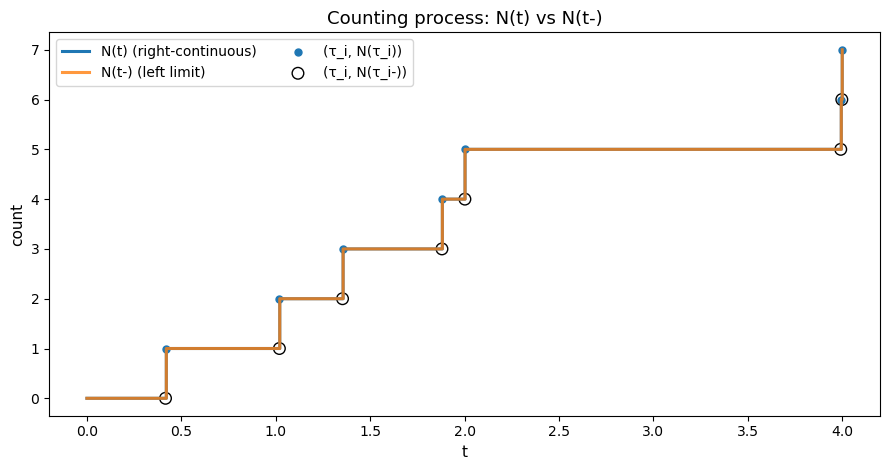

**Figure 1.** At a jump time τ, N(τ) already includes the jump, while N(τ-) is the pre-jump value. Predictability means: use the pre-jump value.

In [3]:
T, lam = 4.0, 1.7
tau = simulate_poisson_jump_times(T, lam, rng)
t_grid = np.linspace(0.0, T, 800)

Nt = N_of_t(t_grid, tau)
Nt_minus = N_of_t_minus(t_grid, tau)

plt.figure()
plt.step(t_grid, Nt, where="post", linewidth=2.2, label="N(t) (right-continuous)")
plt.step(t_grid, Nt_minus, where="post", linewidth=2.2, alpha=0.8, label="N(t-) (left limit)")
if len(tau) > 0:
    k = np.arange(1, len(tau)+1)
    plt.scatter(tau, k, s=25, label="(τ_i, N(τ_i))")
    plt.scatter(tau, k-1, facecolors="none", edgecolors="black", s=70, label="(τ_i, N(τ_i-))")
plt.title("Counting process: N(t) vs N(t-)")
plt.xlabel("t"); plt.ylabel("count")
plt.legend(ncol=2)
plt.tight_layout(); plt.show()

show_caption(
    "At a jump time τ, N(τ) already includes the jump, while N(τ-) is the pre-jump value. "
    "Predictability means: use the pre-jump value."
)

## 3. From $N_t$ to the Poisson random measure $N(dt,dz)$

A **marked point process** is a sequence $(T_i, Z_i)$:
- $T_i$: jump times
- $Z_i$: marks (jump sizes, claim sizes, labels, etc.)

Define a random counting measure on time×mark space:
$$
N((0,t]\times A) := \#\{i: T_i\le t,\ Z_i\in A\}.
$$

Heuristically, $N(dt,dz)$ counts jumps in the tiny rectangle $(t,t+dt]\times(dz)$.

### “Integral = sum over jumps”
For a function $h(t,z)$:
$$
\int_0^T\!\!\int h(t,z)\,N(dt,dz) 
= \sum_{i: T_i\le T} h(T_i, Z_i).
$$


## 4. Predictability: why $H(T_i^-, Z_i)$ is the stochastic integral

In semimartingale theory, the stochastic integral is defined for **predictable** integrands.
For Poisson / jump processes this forces evaluation at the **left limit**.

### A concrete marked analogue
Let the integrand be
$$
H(t,z)=N(t^-)\,\phi(z).
$$
Compare it with the illegal “peek”
$$
H_{\text{bad}}(t,z)=N(t)\,\phi(z).
$$
At the $i$-th jump, $N(T_i^-)=i-1$ while $N(T_i)=i$, so the post-jump version adds one extra $\phi(Z_i)$ at every jump.


In [4]:
def phi(z):
    return z

def integral_pred(N_prejump_at_jump, z):
    return np.sum(N_prejump_at_jump * phi(z))

def integral_bad(N_postjump_at_jump, z):
    return np.sum(N_postjump_at_jump * phi(z))

T, lam = 4.0, 1.5
mark_sampler = lambda rng: rng.standard_normal()
tau, z = simulate_marked_poisson(T, lam, mark_sampler, rng)
n = len(tau)

N_pre = np.arange(n)          # N(T_i-) = i-1
N_post = np.arange(1, n+1)    # N(T_i)  = i

I_pred = integral_pred(N_pre, z)
I_bad  = integral_bad(N_post, z)
I_diff = I_bad - I_pred

print("n =", n)
print("Σ N(T_i-) φ(Z_i) =", I_pred)
print("Σ N(T_i)  φ(Z_i) =", I_bad)
print("difference        =", I_diff)
print("Σ φ(Z_i)          =", np.sum(phi(z)))

print("Replacing N(t-) by N(t) adds exactly one φ(Z_i) per jump (i.e. you counted the jump inside the integrand).")

n = 8
Σ N(T_i-) φ(Z_i) = -22.98434751938759
Σ N(T_i)  φ(Z_i) = -29.893833119487223
difference        = -6.909485600099632
Σ φ(Z_i)          = -6.909485600099634
Replacing N(t-) by N(t) adds exactly one φ(Z_i) per jump (i.e. you counted the jump inside the integrand).


### Visual: per-jump contributions


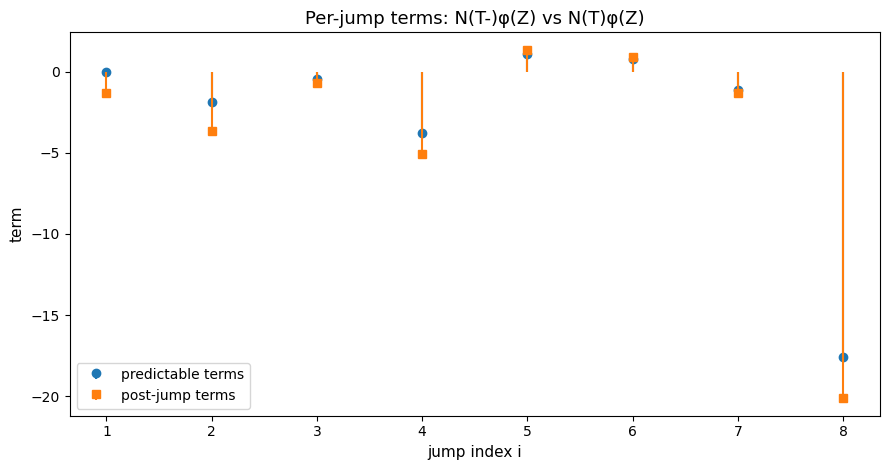

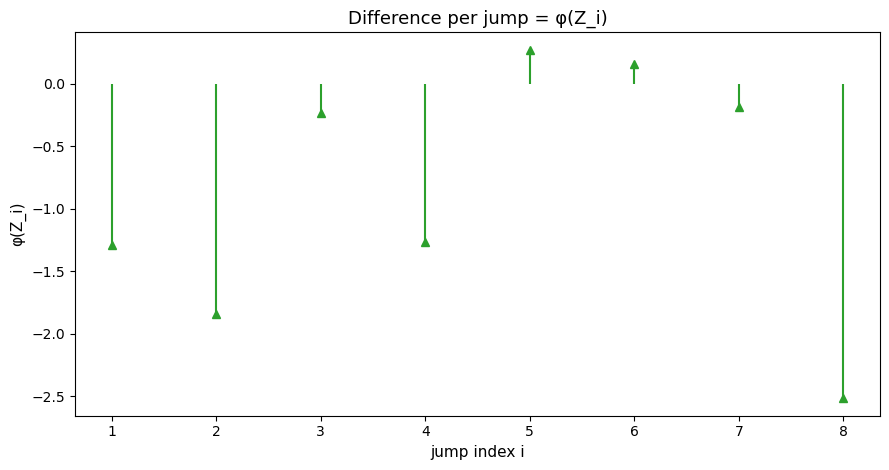

**Figure 2.** The difference per jump is exactly φ(Z_i): this is the 'extra peek' you get by using N(t).

In [5]:
if n == 0:
    print("No jumps occurred in this path; re-run to get a nontrivial picture.")
else:
    pred_terms = N_pre * phi(z)
    bad_terms  = N_post * phi(z)
    diff_terms = bad_terms - pred_terms

    plt.figure()
    plt.stem(np.arange(1, n+1), pred_terms, linefmt="C0-", markerfmt="C0o", basefmt=" ", label="predictable terms")
    plt.stem(np.arange(1, n+1), bad_terms,  linefmt="C1-", markerfmt="C1s", basefmt=" ", label="post-jump terms")
    plt.title("Per-jump terms: N(T-)φ(Z) vs N(T)φ(Z)")
    plt.xlabel("jump index i"); plt.ylabel("term")
    plt.legend(); plt.tight_layout(); plt.show()

    plt.figure()
    plt.stem(np.arange(1, n+1), diff_terms, linefmt="C2-", markerfmt="C2^", basefmt=" ")
    plt.title("Difference per jump = φ(Z_i)")
    plt.xlabel("jump index i"); plt.ylabel("φ(Z_i)")
    plt.tight_layout(); plt.show()

    show_caption("The difference per jump is exactly φ(Z_i): this is the 'extra peek' you get by using N(t).")

## 5. Compensation: $\tilde N(dt,dz)=N(dt,dz)-\nu(dz)\,dt$

For a Poisson random measure with intensity $\nu(dz)\,dt$, define the **compensated** measure
$$
\tilde N(dt,dz):=N(dt,dz)-\nu(dz)\,dt.
$$

In the compound Poisson model (rate $\lambda$, mark law $F$):
$$
\nu(dz)=\lambda F(dz),\qquad
\int_0^t\!\!\int g(z)\,\tilde N(ds,dz)
=\sum_{T_i\le t} g(Z_i) - \lambda t\,\mathbb E[g(Z)].
$$

The compensation term is the predictable drift; subtracting it “centers” the jump noise.


In [6]:
def compensated_integral_g(T, lam, g, mark_sampler, Eg, n_paths=12000):
    vals = []
    for _ in range(n_paths):
        tau, z = simulate_marked_poisson(T, lam, mark_sampler, rng)
        vals.append(np.sum(g(z)) - lam*T*Eg)
    return float(np.mean(vals)), float(np.std(vals))

T, lam = 2.0, 2.5
mark_sampler = lambda rng: rng.standard_normal()

# g(z)=z (mean 0), and g(z)=z^2 (mean 1 for N(0,1))
g1, Eg1 = (lambda z: z), 0.0
g2, Eg2 = (lambda z: z**2), 1.0

m1, s1 = compensated_integral_g(T, lam, g1, mark_sampler, Eg1)
m2, s2 = compensated_integral_g(T, lam, g2, mark_sampler, Eg2)

print("E[∫∫ z  dÑ]   ≈", m1, "   std ≈", s1)
print("E[∫∫ z^2 dÑ] ≈", m2, "   std ≈", s2)

print("Monte Carlo: compensated integrals have near-zero mean (the predictable drift has been removed).")

E[∫∫ z  dÑ]   ≈ 0.022445956021573114    std ≈ 2.240639792576247
E[∫∫ z^2 dÑ] ≈ -0.053882112600891936    std ≈ 3.79822618153035
Monte Carlo: compensated integrals have near-zero mean (the predictable drift has been removed).


## 6. Jump SDEs: why coefficients use $X_{t^-}$

A jump SDE template:
$$
dX_t=b(X_{t^-})\,dt+\int \gamma(X_{t^-},z)\,N(dt,dz)
\quad\text{or}\quad
dX_t=b(X_{t^-})\,dt+\int \gamma(X_{t^-},z)\,\tilde N(dt,dz).
$$

At a jump time $T_i$, the update is explicit:
$$
X_{T_i}=X_{T_i^-}+\gamma(X_{T_i^-},Z_i).
$$

If you wrote $\gamma(X_t,z)$ instead, you would be solving an **implicit equation at every jump**, and you would also violate predictability.


## 7. Visual experiment: jump-driven mean reversion

We simulate a jump-driven OU / shot-noise style process:
$$
dX_t=-\kappa X_t\,dt + \int z\,N(dt,dz),
$$
so between jumps it decays, and at each jump time $T_i$:
$$
X_{T_i}=X_{T_i^-}+Z_i.
$$


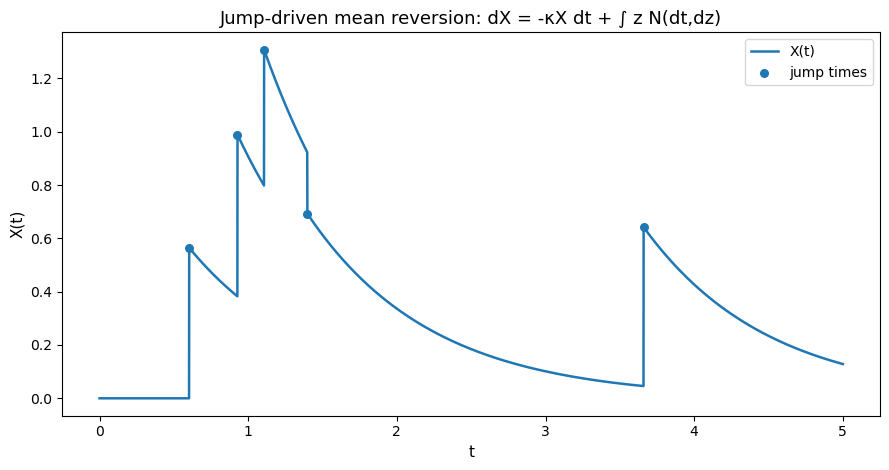

**Figure 3.** Between jumps the drift acts; at jumps you add the mark Z. This is the X(t-) convention in action.

In [7]:
def simulate_jump_OU(T, kappa, lam, mark_sampler, dt=0.001, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    t_grid = np.arange(0.0, T+dt, dt)
    tau, z = simulate_marked_poisson(T, lam, mark_sampler, rng)

    X = np.zeros_like(t_grid)
    jump_ptr = 0

    for i in range(1, len(t_grid)):
        t_prev, t_now = t_grid[i-1], t_grid[i]
        X[i] = X[i-1] - kappa * X[i-1] * dt

        while jump_ptr < len(tau) and (t_prev < tau[jump_ptr] <= t_now):
            X[i] += z[jump_ptr]
            jump_ptr += 1
    return t_grid, X, tau, z

T = 5.0
kappa = 1.2
lam = 1.0
mark_sampler = lambda rng: 0.7*rng.standard_normal()

t_grid, X, tau, z = simulate_jump_OU(T, kappa, lam, mark_sampler, dt=0.001, rng=rng)

plt.figure()
plt.plot(t_grid, X, linewidth=1.8, label="X(t)")
if len(tau) > 0:
    idx = np.searchsorted(t_grid, tau, side="left")
    idx = np.clip(idx, 1, len(t_grid)-1)
    plt.scatter(tau, X[idx], s=30, label="jump times")
plt.title("Jump-driven mean reversion: dX = -κX dt + ∫ z N(dt,dz)")
plt.xlabel("t"); plt.ylabel("X(t)")
plt.legend(); plt.tight_layout(); plt.show()

show_caption("Between jumps the drift acts; at jumps you add the mark Z. This is the X(t-) convention in action.")